<a href="https://colab.research.google.com/github/VattamYasritha/Deep_Learning/blob/main/Experiment%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features Shape :", X.shape)
print("Labels Shape :", y.shape)

Features Shape : (569, 30)
Labels Shape : (569,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [5]:
model_mse = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mse.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
history_mse = model_mse.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8286 - loss: 0.1843 - val_accuracy: 0.8684 - val_loss: 0.1480
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9143 - loss: 0.1215 - val_accuracy: 0.9211 - val_loss: 0.0954
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9451 - loss: 0.0802 - val_accuracy: 0.9561 - val_loss: 0.0649
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9560 - loss: 0.0586 - val_accuracy: 0.9561 - val_loss: 0.0491
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9626 - loss: 0.0464 - val_accuracy: 0.9561 - val_loss: 0.0413
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9692 - loss: 0.0386 - val_accuracy: 0.9561 - val_loss: 0.0354
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9736 - loss: 0.0331 - val_accuracy: 0.9561 - val_loss: 0.0319
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0294 - val_accuracy: 0.9561 - val_loss

In [7]:
loss_mse, acc_mse = model_mse.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("MSE Loss :", loss_mse)
print("MSE Accuracy :", acc_mse)

MSE Loss : 0.026476794853806496
MSE Accuracy : 0.9649122953414917


In [8]:
model_bce = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bce.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history_bce = model_bce.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3473 - loss: 0.9904 - val_accuracy: 0.4474 - val_loss: 0.7472
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6857 - loss: 0.6002 - val_accuracy: 0.7895 - val_loss: 0.5073
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8659 - loss: 0.4102 - val_accuracy: 0.8860 - val_loss: 0.3562
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9319 - loss: 0.2952 - val_accuracy: 0.9211 - val_loss: 0.2540
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9516 - loss: 0.2252 - val_accuracy: 0.9561 - val_loss: 0.1921
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9626 - loss: 0.1806 - val_accuracy: 0.9649 - val_loss: 0.1501
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1505 - val_accuracy: 0.9649 - val_loss: 0.1273
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9714 - loss: 0.1293 - val_accuracy: 0.9649 - val_loss

In [10]:
loss_bce, acc_bce = model_bce.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Binary Cross Entropy Loss :", loss_bce)
print("Binary Cross Entropy Accuracy :", acc_bce)

Binary Cross Entropy Loss : 0.07327542454004288
Binary Cross Entropy Accuracy : 0.9824561476707458


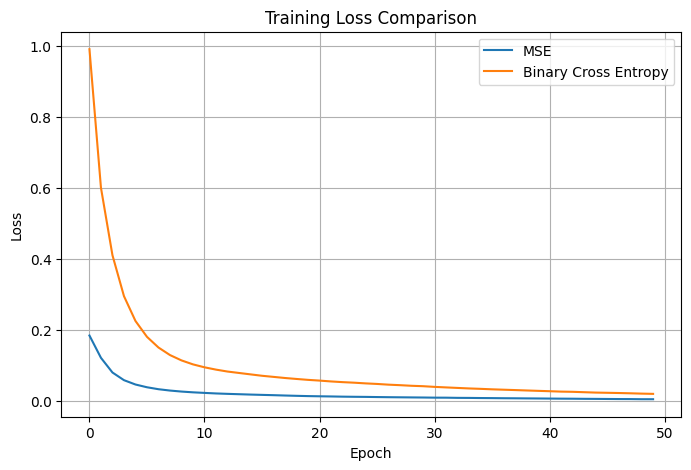

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history_mse.history['loss'], label='MSE')

plt.plot(history_bce.history['loss'], label='Binary Cross Entropy')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

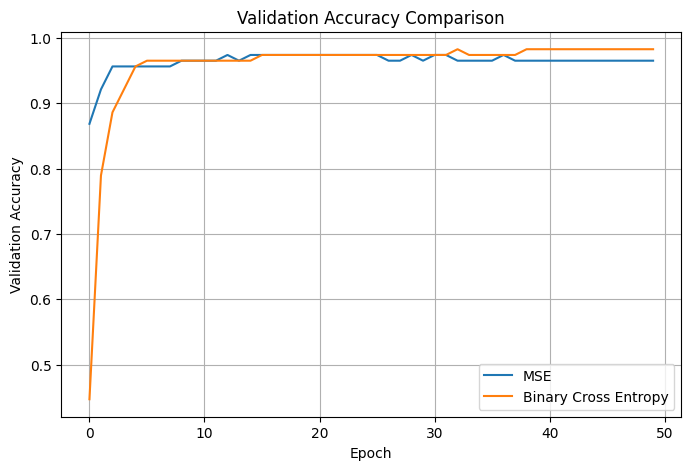

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history_mse.history['val_accuracy'], label='MSE')

plt.plot(history_bce.history['val_accuracy'], label='Binary Cross Entropy')

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
prediction = model_bce.predict(X_test)

prediction = (prediction > 0.5).astype(int)

print(prediction[:20])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]]


In [14]:
print(y_test[:20])

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]


In [15]:
comparison = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": prediction[:20].flatten()
})

print(comparison)

    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        1          1
9        1          1
10       1          1
11       0          0
12       1          1
13       0          0
14       1          1
15       0          0
16       1          1
17       1          1
18       1          1
19       0          0


In [16]:
results = pd.DataFrame({
    "Model": ["MSE", "Binary Cross Entropy"],
    "Loss": [loss_mse, loss_bce],
    "Accuracy": [acc_mse*100, acc_bce*100]
})

print(results)

                  Model      Loss   Accuracy
0                   MSE  0.026477  96.491230
1  Binary Cross Entropy  0.073275  98.245615
